<a href="https://colab.research.google.com/github/jylin04/mi-ntk/blob/main/gemma_3_270m.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup (Run this at start)

In [1]:
%pip -q install -U transformers safetensors accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 76.5 MB/s eta 0:00:00


In [2]:
import torch as t
from transformers import AutoTokenizer, AutoModelForCausalLM

#1. Import and play with the model

In [3]:
from google.colab import userdata
from huggingface_hub import login

login(userdata.get("HF_TOKEN"))

In [4]:
model_id = "google/gemma-3-270m"   # for instruction-tuned use "google/gemma-3-270m-it"
tokenizer = AutoTokenizer.from_pretrained(model_id, use_fast = True)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    device_map="auto",
    #dtype=t.bfloat16 if t.cuda.is_available() else t.float32,
    dtype = t.float32
)

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/536M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/133 [00:00<?, ?B/s]

In [5]:
# Example of open-ended generation
message = "How do I bake potatoes?"

inputs = tokenizer(message, return_tensors="pt").to(model.device)
out = model.generate(**inputs, max_new_tokens=10)
print(tokenizer.decode(out[0], skip_special_tokens=True))

How do I bake potatoes? This is a bit of a challenge. Most recipes


# 2. Construct the dataset

We'll use the TinyStories dataset to try to get a signal.

In [6]:
from datasets import load_dataset

# Load TinyStories from Hugging Face
ds = load_dataset("roneneldan/TinyStories")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…):   0%|          | 0.00/249M [00:00<?, ?B/s]

data/train-00001-of-00004-5852b56a2bd28f(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/train-00002-of-00004-a26307300439e9(…):   0%|          | 0.00/246M [00:00<?, ?B/s]

data/train-00003-of-00004-d243063613e5a0(…):   0%|          | 0.00/248M [00:00<?, ?B/s]

data/validation-00000-of-00001-869c898b5(…):   0%|          | 0.00/9.99M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

We'll also use Stanza: a NLP package in Python that provides linguistically motivated labels of words: punctuation, pronoun, proper noun, noun/verb/adjective/... etc.

In [7]:
%pip install -q stanza

import stanza

stanza.download('en')      # replace 'en' with your language code if needed
nlp = stanza.Pipeline('en')

doc = nlp("Barack Obama was born in Hawaii.")
print(doc)
print(doc.entities)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 73.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 773.7/773.7 kB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 39.6 MB/s eta 0:00:00


INFO:stanza:Downloaded file to /root/.cache/stanza/1.12.0/resources/resources.json
INFO:stanza:Downloading default packages for language: en (English) ...


INFO:stanza:Downloaded file to /root/.cache/stanza/1.12.0/resources/en/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.12.0/resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.12.0/resources/resources.json
INFO:stanza:Loading these models for language: en (English):
| Processor    | Package                   |
--------------------------------------------
| tokenize     | combined                  |
| mwt          | combined                  |
| pos          | combined_charlm           |
| lemma        | combined_nocharlm         |
| constituency | ptb3-revised_charlm       |
| depparse     | combined_charlm           |
| sentiment    | sstplus_charlm            |
| ner          | ontonotes-ww-multi_charlm |

INFO:stanza:Using device: cuda
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Loading: constituency
INFO:stanza:Loading: depparse
INFO:stanza:Loading: sentiment
INFO:stanza:Loading: ner
INFO:stanza:Done loading processors!


[
  [
    {
      "id": 1,
      "text": "Barack",
      "lemma": "Barack",
      "upos": "PROPN",
      "xpos": "NNP",
      "feats": "Number=Sing",
      "head": 4,
      "deprel": "nsubj:pass",
      "start_char": 0,
      "end_char": 6,
      "ner": "B-PERSON",
      "multi_ner": [
        "B-PERSON"
      ]
    },
    {
      "id": 2,
      "text": "Obama",
      "lemma": "Obama",
      "upos": "PROPN",
      "xpos": "NNP",
      "feats": "Number=Sing",
      "head": 1,
      "deprel": "flat",
      "start_char": 7,
      "end_char": 12,
      "ner": "E-PERSON",
      "multi_ner": [
        "E-PERSON"
      ]
    },
    {
      "id": 3,
      "text": "was",
      "lemma": "be",
      "upos": "AUX",
      "xpos": "VBD",
      "feats": "Mood=Ind|Number=Sing|Person=3|Tense=Past|VerbForm=Fin",
      "head": 4,
      "deprel": "aux:pass",
      "start_char": 13,
      "end_char": 16,
      "ner": "O",
      "multi_ner": [
        "O"
      ]
    },
    {
      "id": 4,
      "text": "b

In [8]:
stz = stanza.Pipeline("en", processors="tokenize,mwt,pos,lemma", verbose=False)

We use a blacklist approach to build the stratfied dataset: Draw random samples from TinyStories to populate each POS category up to a set number, keeping only those where the model's next POS prediction agrees with the POS for the next TS token.   

In [ ]:
import random
from collections import defaultdict

from tqdm.auto import tqdm


def parse_ud_feats(feats: str) -> dict:
    """
    Helper function to parse a Stanza morphological features string.

    Input:
      Stanza feats string like "Number=Sing|Tense=Past"
    Output:
      Python dict like {'Number': 'Sing', 'Tense': 'Past'}.
    """

    # Handles missing features. In Stanza, "_" means no features.
    if not feats or feats == "_":
        return {}

    # Build the dictionary.
    out = {}
    for item in feats.split("|"):
        if "=" in item:
            k, v = item.split("=", 1)
            out[k] = v
    return out




from bisect import bisect_right

def sample_prefix_candidate_from_story(
    text: str,
    tokenizer,
    stz,
    context_len: int,
    rng,
    allowed_ts_tags=None,
)-> dict | None:
    """
    Helper function to return one random prefix candidate from text (context_ids + TS-predicted source token), along with lots of metadata about it.
    The returned candidate is randomly selected from all appropriate-length context windows where the last (source) token is in acceptable POS's.

    Inputs:
      text: the story
      tokenizer: model tokenizer
      stz: Stanza function used to parse the teext
      context_len: length of sample to keep
      rng= random number generator
      allowed_ts_tags = only keep last tokens whose POS tag is in this category.

    Outputs: Dictionary containing
      prefix_text: the raw story text ending immediately before the last token.
      context_ids: the tokens of the prefixed sample.
      story_char_* : the character span of the source token.
      source_token_text: the text of the last token.
      ts_label: POS label of the last token.
      ts_feats_raw: raw morphological string of the last token.
      ts_feats: parsed morphlogical features of the last token.
      ts_lemma: lemma of the last token.
      ts_word_text: text of the last token.

    """
    # Run Stanza on the story
    doc = stz(text)

    # Tokenize the story.
    enc = tokenizer(
        text,
        add_special_tokens=False,
        return_offsets_mapping=True,
    )
    input_ids = enc["input_ids"]
    offsets = enc["offset_mapping"]

    if offsets is None:
        raise ValueError("Tokenizer must support return_offsets_mapping; use a fast tokenizer.")

    if allowed_ts_tags is not None:
        allowed_ts_tags = set(allowed_ts_tags)

    token_ends = [end for _, end in offsets]

    chosen = None
    n_valid = 0


    # Loop over Stanza-parsed sentences
    for sent in doc.sentences:
        # Loop over tokens in each sentence
        for tok in sent.tokens:
            if len(tok.words) != 1:
                continue

            # Get POS tag for the word
            word = tok.words[0]
            ts_label = word.upos


            # Keep sample if POS tag is allowed & there's enough tokens before it
            if allowed_ts_tags is not None and ts_label not in allowed_ts_tags:
                continue

            n_prefix_tokens = bisect_right(token_ends, tok.start_char)
            if n_prefix_tokens < context_len:
                continue

            n_valid += 1
            # With probability 1/(number of valid samples) so far, upgrade the chosen sample to the current one.
            if rng.randrange(n_valid) == 0:
                chosen = {
                    "prefix_end": tok.start_char,
                    "context_ids": input_ids[n_prefix_tokens - context_len:n_prefix_tokens],
                    "story_char_start": tok.start_char,
                    "story_char_end": tok.end_char,
                    "source_token_text": tok.text,
                    "ts_label": ts_label,
                    "ts_feats_raw": word.feats,
                    "ts_feats": parse_ud_feats(word.feats),
                    "ts_lemma": word.lemma,
                    "ts_word_text": tok.text,
                }

    if chosen is None:
        return None

    return {
        "prefix_text": text[:chosen["prefix_end"]],
        "context_ids": chosen["context_ids"],
        "story_char_start": chosen["story_char_start"],
        "story_char_end": chosen["story_char_end"],
        "source_token_text": chosen["source_token_text"],
        "ts_label": chosen["ts_label"],
        "ts_feats_raw": chosen["ts_feats_raw"],
        "ts_feats": chosen["ts_feats"],
        "ts_lemma": chosen["ts_lemma"],
        "ts_word_text": chosen["ts_word_text"],
    }






def first_generated_word_labels(
    prefix_text: str,
    new_ids,
    tokenizer,
    stz
    ) -> dict | None:
    """
    Helper function to find the UPOS/morphological features of the *model-generated* next word that (fully) begins after a prefix. (To compare w/TS data)

    Inputs:
      prefix_text: raw prefix text before the generated continuation.
      new_ids: *model-generated* next ID's.
      tokenizer: model tokenizer
      stz: Stanza function used to parse the teext

    Outputs: Dictionary containing POS/morphological data about the next word in new IDs, given preceding context.
    """
    if len(new_ids) == 0:
        return None

    # Turn the new_id tokens into text
    new_text = tokenizer.decode(new_ids, clean_up_tokenization_spaces=False)
    if new_text == "":
        return None

    # Run Stanza on full text with new words appended.
    full_text = prefix_text + new_text
    doc = stz(full_text)

    # Store the boundary between the old and new text.
    prefix_end = len(prefix_text)

    # Return a dictionary describing the Stanza properties of the first generated word.
    for sent in doc.sentences:
        for tok in sent.tokens:
            if tok.start_char >= prefix_end:
                if len(tok.words) != 1:
                    return None
                word = tok.words[0]
                return {
                    "pred_label": word.upos,
                    "pred_feats_raw": word.feats,
                    "pred_feats": parse_ud_feats(word.feats),
                    "pred_lemma": word.lemma,
                    "pred_word_text": tok.text,
                    "generated_text": new_text,
                }

    return None







def greedy_generate_first_word_labels(
    model,
    tokenizer,
    stz,
    candidates: list[dict],
    max_new_tokens: int =3,
    batch_size: int =32,
)-> list[dict]:
    """
    Helper function to take a list of prefix candidates (contexts), generate a short continuation for eaech and label the model's next word.

    Inputs:
      model: model
      tokenizer: tokenizer
      stz: Stanza function used to parse the teext
      candidates: list of dictionaries, each of which stores a context window w/metadata
      max_new_tokens: number of tokens we'll have the model greedily genrate after each context window
      batch_size = batch size

    Output:
      list of dictionaries, each of which stores metadata about the model-generated next word for the corresponding context.
      The output dictionaries are paired to the input context windows by list position.
    """
    device = model.get_input_embeddings().weight.device
    labeled = []

    model.eval()
    with t.no_grad():

        # Loop over the candidates in chunks of size batch_size.
        for i in tqdm(range(0, len(candidates), batch_size), desc="Generating labels"):
            batch = candidates[i:i + batch_size]

            input_ids = t.tensor([c["context_ids"] for c in batch], dtype=t.long, device=device)
            attention_mask = t.ones_like(input_ids)

            # Ask the model to greedily generate continuations for the batch, up to max_new_tokens.
            out = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                use_cache=True,
                pad_token_id=tokenizer.eos_token_id,
            )

            # Store the newly-generated part in new_ids.
            new_ids = out[:, input_ids.shape[1]:].cpu()

            # For each generated item, labele the first generated word w/the previous function.
            for j, c in enumerate(batch):
                info = first_generated_word_labels(
                    prefix_text=c["prefix_text"],
                    new_ids=new_ids[j].tolist(),
                    tokenizer=tokenizer,
                    stz=stz,
                )

                # Append the labeled candidate to the output list.
                c = dict(c)
                if info is not None:
                    c.update(info)
                else:
                    c["pred_label"] = None
                    c["pred_feats_raw"] = None
                    c["pred_feats"] = {}
                    c["pred_lemma"] = None
                    c["pred_word_text"] = None
                    c["generated_text"] = tokenizer.decode(
                        new_ids[j].tolist(),
                        clean_up_tokenization_spaces=False,
                    )
                labeled.append(c)

    return labeled









def build_tinystories_model_upos_quota_dataset_greedy(
    ds,
    tokenizer,
    model,
    stz,
    target_tags,
    n_per_tag: int,
    split="train",
    context_len=64,
    seed=0,
    max_stories=None,
    story_batch_size=256,
    model_batch_size=32,
    max_new_tokens=6,
    require_pos_agreement=True,
):
    """
    Build a balanced dataset where labels come from the model's own greedy
    first generated word.

    If require_pos_agreement=True, only keep examples where the POS of the
    model's first generated word matches the POS of the TinyStories source token
    at the same boundary.
    """
    rng = random.Random(seed)
    target_tags = list(target_tags)
    target_tag_set = set(target_tags)

    story_indices = list(range(len(ds[split])))
    rng.shuffle(story_indices)
    if max_stories is not None:
        story_indices = story_indices[:max_stories]

    buckets = {tag: [] for tag in target_tags}

    def done():
        return all(len(buckets[tag]) >= n_per_tag for tag in target_tags)

    def counts_str():
        return " ".join(f"{tag}:{len(buckets[tag])}/{n_per_tag}" for tag in target_tags)

    ptr = 0
    pbar = tqdm(total=len(story_indices), desc="Scanning stories")

    while ptr < len(story_indices) and not done():
        candidates = []

        while ptr < len(story_indices) and len(candidates) < story_batch_size:
            story_idx = story_indices[ptr]
            ptr += 1
            pbar.update(1)

            text = ds[split][story_idx]["text"]
            c = sample_prefix_candidate_from_story(
                text=text,
                tokenizer=tokenizer,
                stz=stz,
                context_len=context_len,
                rng=rng,
                allowed_ts_tags=target_tag_set if require_pos_agreement else None,
            )
            if c is None:
                pbar.set_postfix_str(counts_str())
                continue

            c["story_idx"] = story_idx
            candidates.append(c)
            pbar.set_postfix_str(counts_str())

        if len(candidates) == 0:
            break

        labeled = greedy_generate_first_word_labels(
            model=model,
            tokenizer=tokenizer,
            stz=stz,
            candidates=candidates,
            max_new_tokens=max_new_tokens,
            batch_size=model_batch_size,
        )

        by_tag = defaultdict(list)
        for c in labeled:
            pred_tag = c["pred_label"]
            ts_tag = c.get("ts_label")

            c["pos_agrees_with_ts"] = (
                pred_tag is not None
                and ts_tag is not None
                and pred_tag == ts_tag
            )

            if require_pos_agreement and not c["pos_agrees_with_ts"]:
                continue

            tag = pred_tag
            if tag in target_tag_set and len(buckets[tag]) < n_per_tag:
                by_tag[tag].append(c)

        for tag in target_tags:
            if len(buckets[tag]) >= n_per_tag:
                continue
            if len(by_tag[tag]) == 0:
                continue

            rng.shuffle(by_tag[tag])
            need = n_per_tag - len(buckets[tag])
            buckets[tag].extend(by_tag[tag][:need])

        pbar.set_postfix_str(counts_str())

    pbar.close()

    sampled = []
    for tag in target_tags:
        sampled.extend(buckets[tag])

    contexts = [x["context_ids"] for x in sampled]
    labels = [x["pred_label"] for x in sampled]   # same as ts_label on kept examples if require_pos_agreement=True
    lemmas = [x["pred_lemma"] for x in sampled]
    metadata = sampled

    if len(sampled) == 0:
        contexts_t = t.empty((0, context_len), dtype=t.long)
    else:
        contexts_t = t.tensor(contexts, dtype=t.long)

    counts = {tag: len(buckets[tag]) for tag in target_tags}
    return contexts_t, labels, lemmas, metadata, counts, done()

In [ ]:
target_tags = ["PUNCT", "PRON", "PROPN", "DET", "ADV", "CCONJ", "NOUN", "VERB"]


contexts_model_t, labels_model, lemmas_model, metadata_model, counts_model, ok = \
    build_tinystories_model_upos_quota_dataset_greedy(
        ds=ds,
        tokenizer=tokenizer,
        model=model,
        stz=stz,
        target_tags=target_tags,
        n_per_tag=128,
        split="train",
        context_len=64,
        seed=0,
        max_stories=15000,
        story_batch_size=256,
        model_batch_size=32,
        max_new_tokens=3,
        require_pos_agreement=True,
    )

Scanning stories:   0%|          | 0/15000 [00:00<?, ?it/s]

Generating labels:   0%|          | 0/8 [00:00<?, ?it/s]

Generating labels:   0%|          | 0/8 [00:00<?, ?it/s]

Generating labels:   0%|          | 0/8 [00:00<?, ?it/s]

Generating labels:   0%|          | 0/8 [00:00<?, ?it/s]

Generating labels:   0%|          | 0/8 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Code to SAVE the dataset to google drive

'''from google.colab import drive
import torch as t

drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/tinystories_upos_dataset.pt'

payload = {
    "contexts_t": contexts_model_t.cpu(),   # tensor
    "labels": labels_model,                 # list[str]
    "lemmas": lemmas_model,                 # list[str | None]
    "metadata": metadata_model,             # list[dict]
    "counts": counts_model,                 # dict[tag, int]
}

t.save(payload, save_path)
print(f"saved to {save_path}")'''

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
saved to /content/drive/MyDrive/tinystories_upos_dataset.pt


In [11]:
# Code to RETRIEVE the saved dataset from google drive.

import torch as t
from google.colab import drive

drive.mount('/content/drive')

save_path = '/content/drive/MyDrive/tinystories_upos_dataset.pt'
payload = t.load(save_path)

contexts_model_t = payload["contexts_t"]
labels_model = payload["labels"]
lemmas_model = payload["lemmas"]
metadata_model = payload["metadata"]
counts_model = payload["counts"]

Mounted at /content/drive


In [12]:
# Check that the retrieved dataset is correct.

i = 0
text = tokenizer.decode(contexts_model_t[i].tolist(), clean_up_tokenization_spaces=False)
print(text)

 into the mixer. The mixer went round and round. It made a soft, yummy cake mix. Lily was happy. She took the mix and put it in a pan.

Lily's mom came into the kitchen. She saw the cake mix in the pan. "What are you doing, Lily?" Mom asked


In [13]:
batch_full = {
    "input_ids": contexts_model_t,
    "attention_mask": t.ones_like(contexts_model_t),            # dummy no-padding mask
}

# 3. Compute approximate top eNTK eigenvectors.

Next we define a function that can do matrix multiplication on + run Lanczos on the operator \tilde K defined in the paper.

In [14]:
import gc
from typing import Dict
from transformers import PreTrainedModel
from torch.func import functional_call, vjp, jvp


def matvec_tildeK_fixedT_layers(
    model: PreTrainedModel,
    batch: Dict[str, t.Tensor],
    w: t.Tensor,
    layers: list[int],
    chunk_size: int,
) -> t.Tensor:

    """
    Compute y = \tilde K * w for

        \tilde K = S^{1/2} K_r S^{1/2},    (shape (N*d_model, N*d_model))

        K_r = J_r J_r^T,                   (shape (N*d_model, N*d_model))
        S = U^T U otimes I_N,             (shape (N*d_model, N*d_model))

    where J_r is the Jacobian of the final hidden vector at the last sequence
    position wrt the paramters in layers,

    assuming all sequences in batch have the same length T.

    Inputs:
      model: Huggingface model
      batch: dict with keys 'input_ids' and 'attention_mask'
      w: vector to multiply wrt.          (shape (N*d_model,))
      layers: parameters to differentiate wrt
      chunk_size: minibatch size

    Returns:
      y: \tilde K*w.                      (shape (N*d_model,))
    """

    model.eval()
    device = model.device


    # ----- Get parameters to differentiate wrt -----
    # Get model parameters
    base = getattr(model, model.base_model_prefix)
    params_base_full = dict(base.named_parameters())
    buffers_base = dict(base.named_buffers())

    # Infer transformer block naming convention
    names = list(params_base_full.keys())
    if any(n.startswith("layers.0.") for n in names):
        block = "layers"
    elif any(n.startswith("h.0.") for n in names):
        block = "h"
    else:
        raise ValueError("Cannot infer transformer block prefix.")

    # Restrict differentiation to parameters in requested layers only.
    # sel_params 0 = dictionary of only the parameters we want to differentiate wrt.
    prefixes = [f"{block}.{i}." for i in layers]
    sel_params0 = {
        n: p for n, p in params_base_full.items()
        if any(n.startswith(pref) for pref in prefixes)
    }
    if len(sel_params0) == 0:
        raise ValueError("No parameters matched the requested layer indices.")


    # ----- Define \tilde K and its parts -----
    # Get U
    head = model.get_output_embeddings()
    U = head.weight.detach().to(device=device, dtype=t.float32)    # shape (d_vocab, d_model)
    d_model = U.shape[1]

    # Get dataset size N
    input_ids_full = batch["input_ids"]
    attn_full = batch["attention_mask"]
    N = input_ids_full.shape[0]

    # (Aside: check w has the right length.)
    if w.numel() != N*d_model:
        raise ValueError(f"w must have shape ({N*d_model},), got {tuple(w.shape)}")

    # Define (U^T U)^{1/2} as A: the object that lives inside S^{1/2}. (Since S = U^TU \otimes I and square root acts on each factor in the Kronecker product.)
    # To get the square root, change basis to diagonal basis and take square root of eigenvalues.
    G = U.T @ U                                                   # shape (d_model, d_model)
    evals, evecs = t.linalg.eigh(G)
    evals = evals.clamp_min(0)
    A = (evecs * evals.sqrt().unsqueeze(0)) @ evecs.T             # shape (d_model, d_model)
    A = A.to(dtype=next(iter(sel_params0.values())).dtype)

    # Apply S^{1/2} = A \otimes I_N to x_flat.
    def apply_Shalf(x_flat: t.Tensor) -> t.Tensor:
        x = x_flat.view(d_model, N)                               # x = d_model rows; each of length N
        y = A @ x                                                 # (... mixes the class blocks while leaving the data directions alone)
        return y.reshape(-1)

    # Helpers to deal w/the flattened vectors
    def get_chunk(x_flat: t.Tensor, start: int, end: int) -> t.Tensor:
        """
        Extract a chunk of examples from a class-major flattened vector.
        Inputs:
          x_flat: the shape (N*d_model,) flattened vector we're extracting examples from.
          start, end: indices in N.
        Output: a shape (end - start, d_model) chunk (matching the shape of residual_last).
        """
        x = x_flat.view(d_model, N)                 # (d_model, N)
        return x[:, start:end].T.contiguous()       # (end-start, d_model)

    def set_chunk(x_flat: t.Tensor, start: int, end: int, x_chunk: t.Tensor):
        """
        The inverse operation: Write x_chunk of shape (b, d_model) into x_flat.
        Inputs:
          x_flat: the shape (N*d_model,) flattened vector we're writing into.
          start, end: indices in N.
          x_chunk: the shape (b, d_model) chunk we're writing into x_flat.
        """
        x = x_flat.view(d_model, N)                 # (d_model, N). x points at same storage as x_flat and next line writes into it.
        x[:, start:end] = x_chunk.T



    # ----- Define the function whose Jacobian we want -----
    def residual_last(sel_params: Dict[str, t.Tensor], batch: Dict[str, t.Tensor]) -> t.Tensor:
        """
        Run the model and return the last hidden state at the final token position for each sequence in the batch.
        Inputs:
          sel_params: Parameters to differentiate wrt
          batch: a minibatch

        Output:
          h: shape (N, d_model)
        """
        full = dict(params_base_full)
        full.update(sel_params)

        # Evaluate the model with the selected parameters singled out
        out = functional_call(
            base,
            (full, buffers_base),
            args=(),
            kwargs={**batch, "use_cache": False},
        )
        h = out.last_hidden_state if hasattr(out, "last_hidden_state") else out[0]  # (N, seq_len, d_model)
        return h[:, -1, :]  # (N, d_model)


    # ----- VJP/JVP -----
    # First left multiply by S^{1/2}
    z = apply_Shalf(w.to(device=device, dtype=A.dtype))


    # VJP pass: u = J_r^T z
    u_sel = {k: t.zeros_like(v) for k, v in sel_params0.items()}                    # Parameter-sized accumulator.

    for start in range(0, N, chunk_size):
        end = min(N, start + chunk_size)

        batch_s = {
            "input_ids": input_ids_full[start:end].to(device),
            "attention_mask": attn_full[start:end].to(device),
        }
        z_s = get_chunk(z, start, end).to(device)                                   # Relevant chunk of z = S^{1/2}*w. Shape (b, d_model)

        def s_score(sel_params):
            # Score we'll take gradient of to effectively do the VJP we want.
            r = residual_last(sel_params, batch_s)                                  # (b, d_model) - last hidden layer activations
            return (r * z_s).sum()                                                  # Gradient of r(\theta) * z is desired J_r^T * z

        scl, vjp_fn = vjp(s_score, sel_params0)
        (g,) = vjp_fn(t.ones_like(scl))                                             # desired gradients (shape: params)

        with t.no_grad():
            for k in u_sel:
                u_sel[k].add_(g[k])                                                 # Accumulate over chunks

        del batch_s, z_s, s_score, scl, vjp_fn, g
        gc.collect()
        t.cuda.empty_cache()


    # JVP pass: t_out = J_r u
    t_out = t.empty(N*d_model, device=device, dtype=A.dtype)                        # Accumulator for the final answer.

    for start in range(0, N, chunk_size):
        end = min(N, start + chunk_size)

        batch_s = {
            "input_ids": input_ids_full[start:end].to(device),
            "attention_mask": attn_full[start:end].to(device),
        }

        def f(sel_params):
            return residual_last(sel_params, batch_s)                               # (b, d_model) - last hidden layer actiations

        _, y_s = jvp(f, (sel_params0,), (u_sel,))                                   # (b, d_model) - desired J_r*u

        with t.no_grad():
            set_chunk(t_out, start, end, y_s)

        del batch_s, f, y_s
        gc.collect()
        t.cuda.empty_cache()

    # Final right multiply by S^{1/2}
    y = apply_Shalf(t_out)

    # Memory clean up.
    del u_sel, sel_params0, params_base_full, z, t_out
    gc.collect()
    t.cuda.empty_cache()

    return y

In [15]:
from tqdm.auto import tqdm

def lanczos_top_eigs(matvec, v0: t.Tensor, m: int, k: int):
    """
    Approx top-m eigenpairs of symmetric K using k-step Lanczos.
    Inputs:
      matvec: function(v)->K@v, v shape (N,)
      v0: initial vector, shape (N,)
      m: number of top eigenpairs to return
      k: Lanczos steps (k >= m)
    Returns:
      evals: (m,)  (largest)
      evecs: (N,m)
    """
    q = v0 / t.linalg.norm(v0)
    q_prev = t.zeros_like(q)
    beta_prev = q.new_tensor(0.0)

    Q = []
    alphas = []
    betas = []

    for i in tqdm(range(k)):
        Q.append(q)

        z1 = matvec(q).detach()
        z = z1.detach().cpu()
        del z1
        gc.collect()
        t.cuda.empty_cache()
        t.cuda.ipc_collect()
        z = z.to(q.device)
        alpha = t.dot(q, z)
        z = z - alpha * q - beta_prev * q_prev

        # full re-orthogonalization (more stable than vanilla Lanczos)
        for qi in Q:
            z = z - t.dot(qi, z) * qi

        beta = t.linalg.norm(z)
        alphas.append(alpha)

        if i == k - 1 or beta.item() == 0.0:
            break

        betas.append(beta)
        q_prev, q, beta_prev = q, z / beta, beta

    k_eff = len(alphas)
    a = t.stack(alphas)                          # (k_eff,)
    Ttri = t.diag(a)
    if k_eff > 1:
        b = t.stack(betas[:k_eff - 1])           # (k_eff-1,)
        Ttri = Ttri + t.diag(b, 1) + t.diag(b, -1)

    Ttri_f = Ttri.float()
    evals, S = t.linalg.eigh(Ttri_f)               # ascending
    idx = t.argsort(evals, descending=True)[:m]  # top m

    Qmat = t.stack(Q[:k_eff], dim=1)             # (N, k_eff)
    Qmat_f = Qmat.float()
    evecs = Qmat_f @ S[:, idx]                     # (N, m)
    return evals[idx], evecs

In [16]:
N = 1024*640                                    # N*d_model
w0 = t.randn(N, device=model.device)

NB: It takes a bit under 8 min to run ths code for the top 25 eigenvectors (50 Lanczos cycles) on layer 17 in A100.

For A100 use chunk size 128; for L4 use chunk size 64 (*or smaller, TBD).


In [17]:
evals, evecs = lanczos_top_eigs(lambda v: matvec_tildeK_fixedT_layers(model, batch_full, v, ["16.mlp.down_proj"], chunk_size = 64), w0, m=25, k=50)

  0%|          | 0/50 [00:00<?, ?it/s]

In [18]:
eigvecs = (t.reshape(evecs.T, [25, 640, 1024]).permute(0, 2, 1).cpu().numpy())

In [ ]:
# To generate the table in the paper, I babysat partial loops over layers e.g., tuning chunk size.

'''for i in range(2):
  current = 1 - i  # 0,1
  layer_name = str(current)+".mlp.down_proj"
  evals, evecs = lanczos_top_eigs(lambda v: matvec_tildeK_fixedT_layers(model, batch_full, v, [layer_name], chunk_size = 64), w0, m=25, k=50)
  eigvecs = (t.reshape(evecs.T, [25, 640, 1024]).permute(0, 2, 1).cpu().numpy())
  H, H_mean, pca_components, pca_scores, pca_directions = get_pca_from_layer(model, batch_full, layer_idx=current, k=25)
  results = compare_entk_vs_pca(
    eigvecs=eigvecs,
    pca_directions=pca_directions,
    labels_agree=labels_model,
    train_frac=0.5,
    seed=0,
    class_order=class_order,
  )
  morph_results = compare_entk_vs_pca_binary_tasks(
    entk_scores=results["entk_scores"],
    pca_scores=results["pca_scores"],
    binary_targets=morph_targets,
    train_idx=results["train_idx"],
    test_idx=results["test_idx"],
    task_order=morph_task_order,
    total_counts=morph_total_counts,
  )
  add_layer_results(store,
                  layer_name = current,
                  pos_results=results,
                  morph_results=morph_results
  )'''

 98%|█████████▊| 49/50 [18:23<00:22, 22.53s/it]


In [ ]:
gc.collect()
t.cuda.empty_cache()
t.cuda.ipc_collect()

Eigenspectrum.

Text(0, 0.5, 'log(eigenvalue)')

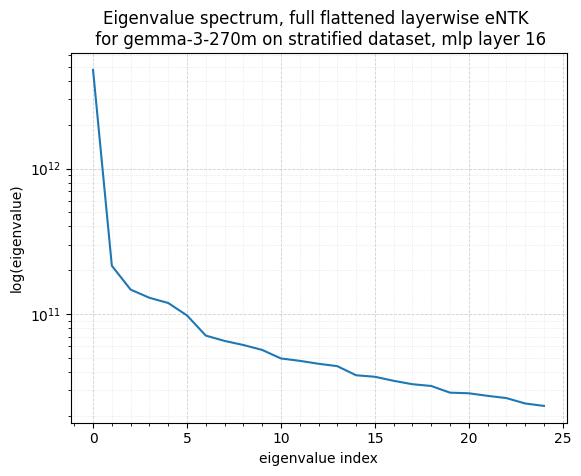

In [20]:
import matplotlib.pyplot as plt

plt.plot(evals.detach().cpu().numpy())
plt.yscale('log')
plt.title("Eigenvalue spectrum, full flattened layerwise eNTK \n for gemma-3-270m on stratified dataset, mlp layer 16")
plt.minorticks_on()
plt.grid(True, which='major', axis='both', linestyle='--', linewidth=0.6, alpha=0.6)
plt.grid(True, which='minor', axis='both', linestyle=':', linewidth=0.5, alpha=0.4)
plt.xlabel("eigenvalue index")
plt.ylabel("log(eigenvalue)")

Examine individual eigenvectors.

In [31]:
import pandas as pd

N = 1024
d_model = 640
U, S, Vh = t.linalg.svd(t.Tensor(eigvecs[10]), full_matrices=False)
svd_score = U[:, 0] * S[0]

vals, idx = svd_score.sort(descending=False)

rows = idx[:20].detach().cpu().tolist()

df = pd.DataFrame({
    "window":  [tokenizer.decode(contexts_model_t[i].detach().cpu().tolist()) for i in rows],
    "Next TS word": [metadata_model[i]['pred_word_text'] for i in rows],
    "POS": [labels_model[i] for i in rows],
})

display(df)

,window,Next TS word,POS
0,"Max tried to run away, but the big dog chased...",look,VERB
1,"One day, her mommy asked her to clean up her ...",make,VERB
2,"help her, so he walked slowly with her. The l...",play,VERB
3,it lit up the whole night sky. It was so beau...,melt,VERB
4,anything like it before and wanted to learn m...,sleep,VERB
5,was very hungry and wanted to eat his meal. H...,know,VERB
6,"nice and cool. From the top, he could see all...",play,VERB
7,brothers. They like to play with their toys. ...,go,VERB
8,child wearing a bright red coat ran up to the...,shine,VERB
9,sun on her face and the people around her tal...,have,VERB


Check most eigenvectors have majority linear projection along top singular direction.

In [32]:
import torch
import matplotlib.pyplot as plt

def plot_top_sv_per_vector(modes):
    # modes: shape (d_model, N, n_vectors)
    s = torch.linalg.svdvals(modes.permute(2, 0, 1).float())  # (n_vectors, min(d_model, N))
    top_sv = s[:, 0].detach().cpu()

    plt.figure()
    plt.plot(range(top_sv.shape[0]), top_sv.numpy(), marker="o")
    plt.xlabel("vector index")
    plt.ylabel("top singular value")
    plt.title("Top singular value per mode")
    plt.show()

# example:
# plot_top_sv_per_vector(modes)

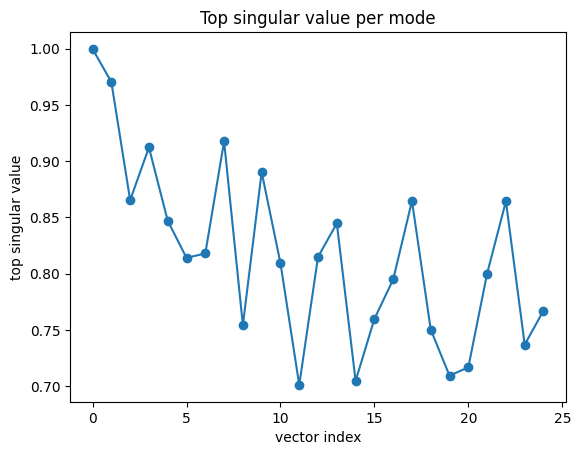

In [33]:
plot_top_sv_per_vector(evecs[:].view(640, 1024, 25))

# 4. Analysis

Compute PCA of the last model layer activations as a baseline.

In [34]:
def get_layer_matrix(
    model,
    batch_full,
    layer_idx=-1,
    batch_size=64) -> t.Tensor:
    """
    Helper function to return a batch of the model's hidden state activations H at layer layer_idx at the last token position.

    (layer_idx = -1: final transformer block output)
    """
    input_ids_all = batch_full["input_ids"]
    attention_mask_all = batch_full["attention_mask"]

    device = model.get_input_embeddings().weight.device
    H_chunks = []

    # Iterate over batches; for each batch, run the batch through the model; and save the desired activations.
    model.eval()
    with t.no_grad():
        for start in range(0, input_ids_all.shape[0], batch_size):
            end = start + batch_size

            input_ids = input_ids_all[start:end].to(device)
            attention_mask = attention_mask_all[start:end].to(device)

            out = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                output_hidden_states=True,
                use_cache=False,
            )

            # hidden_states[0] = embeddings
            # hidden_states[i+1] = output of transformer block i
            if layer_idx == -1:
                h = out.hidden_states[-1]
            else:
                h = out.hidden_states[layer_idx + 1]

            H_chunks.append(h[:, -1, :].cpu())

    H = t.cat(H_chunks, dim=0)   # (N, d_model)
    return H


def get_pca_from_layer(
    model,
    batch_full,
    layer_idx,
    k: int,
    batch_size=64):
    """
    Computes the top k PCA directions on the model activations at layer layer_idx.

    Inputs:
      model: model
      batch_full: batch
      layer_idx: layer number
      k: number of directions to compute
      batch_size: batch size

    Outputs:
      H:               (N, d_model) last-token hidden states from layer_idx
      H_mean:          (d_model,)
      pca_components:  (k, d_model) principal directions in hidden space
      pca_scores:      (k, N) per-example score on each PC
      pca_directions:  (k, N, d_model)
    """
    H = get_layer_matrix(
        model,
        batch_full,
        layer_idx=layer_idx,
        batch_size=batch_size,
    ).float()

    U, S, V = t.pca_lowrank(H, q=k, center=True)

    pca_components = V[:, :k].T       # (k, d_model)
    pca_scores = (U[:, :k] * S[:k]).T # (k, N)
    H_mean = H.mean(dim=0)            # (d_model,)
    pca_directions = t.einsum("kn,kd->knd", pca_scores, pca_components)

    return H, H_mean, pca_components, pca_scores, pca_directions

In [36]:
H, H_mean, pca_components, pca_scores, pca_directions = \
 get_pca_from_layer(model, batch_full, layer_idx=16, k=25)

In [37]:
def top_svd_example_scores(directions):
    """
    Helper function to compute the signed score on directions.

    Input:
      directions: shape (k, N, d) (alt: shape (k,N) is returned directly).

    Output:
      scores of shape (k, N)
    """
    directions = t.Tensor(directions).float()

    if directions.ndim == 2:
        return directions

    k, N, d = directions.shape
    scores = []
    for m in range(k):
        U, S, Vh = t.linalg.svd(directions[m], full_matrices=False)
        scores.append(U[:, 0] * S[0])   # signed score per example
    return t.stack(scores, dim=0)       # (k, N)

## 4.1. Stats metrics and helper functions to generate Table 3

These scripts can be run on a top-k set of eNTK eigenvectors vs. PCA directions at a particular layer. However, the full scripts for computing the top activations over all layers were not cleaned for release.

In [38]:
import random
import numpy as np
import pandas as pd

# ----------------------------
# Basic stats metrics
# ----------------------------

def average_precision_from_scores(scores, y):
    """
    scores: shape (N,)
    y: binary tensor of shape (N,), entries 0/1
    """
    y = y.float()
    P = int(y.sum().item())
    if P == 0:
        return float("nan")

    order = t.argsort(scores, descending=True)
    y_sorted = y[order]

    tp = t.cumsum(y_sorted, dim=0)
    precision = tp / t.arange(1, len(y_sorted) + 1, device=y.device)

    ap = (precision * y_sorted).sum() / P
    return float(ap.item())


def auroc_from_scores(scores, y):
    """
    scores: shape (N,)
    y: binary tensor of shape (N,), entries 0/1
    """
    y = y.float()
    P = float(y.sum().item())
    Nneg = float(len(y) - int(P))

    if P == 0 or Nneg == 0:
        return float("nan")

    order = t.argsort(scores, descending=True)
    y_sorted = y[order]

    tp = t.cumsum(y_sorted, dim=0)
    fp = t.cumsum(1.0 - y_sorted, dim=0)

    tpr = t.cat([t.tensor([0.0], device=y.device), tp / P])
    fpr = t.cat([t.tensor([0.0], device=y.device), fp / Nneg])

    auc = t.trapz(tpr, fpr)
    return float(auc.item())


def precision_and_enrichment_at_quota(scores, y):
    """
    Use k = number of positives in this split.

    returns:
      precision_at_quota, enrichment_at_quota, quota, prevalence
    """
    y = y.float()
    quota = int(y.sum().item())
    if quota == 0:
        return float("nan"), float("nan"), 0, float("nan")

    prevalence = float(y.mean().item())

    order = t.argsort(scores, descending=True)
    top = y[order][:quota]

    precision = float(top.mean().item())
    enrichment = float(precision / prevalence) if prevalence > 0 else float("nan")

    return precision, enrichment, quota, prevalence




# ----------------------------
# Train/test split
# ----------------------------

def stratified_split(
    labels,
    train_frac=0.5,
    seed=0,
    class_order=None):
    """
    Return train/test split by class, preserving (approximately) train_frac train samples per class.

    Outputs:
      train_idx: tensor of indices
      test_idx:  tensor of indices
    """
    if class_order is None:
        class_order = list(dict.fromkeys(labels))

    rng = random.Random(seed)
    idx_by_class = {c: [] for c in class_order}
    for i, lab in enumerate(labels):
        idx_by_class[lab].append(i)

    train_idx = []
    test_idx = []

    for c in class_order:
        idxs = idx_by_class[c][:]
        rng.shuffle(idxs)

        n = len(idxs)
        if n <= 1:
            train_n = n
        else:
            train_n = int(round(train_frac * n))
            train_n = min(max(train_n, 1), n - 1)

        train_idx.extend(idxs[:train_n])
        test_idx.extend(idxs[train_n:])

    train_idx = t.tensor(sorted(train_idx), dtype=t.long)
    test_idx = t.tensor(sorted(test_idx), dtype=t.long)
    return train_idx, test_idx




# ----------------------------
# Evaluate one basis (eNTK or PCA)
# ----------------------------

def evaluate_single_direction_basis(
    score_matrix,          # (k, N)
    labels,                # list of length N
    train_idx,             # tensor of indices
    test_idx,              # tensor of indices
    class_order=None,
):
    """
    For each test category (e.g. POS), choose the best direction and sign on train by AP.
    Then evaluate metrics for that choice on test.

    Output:
      DataFrame with one row per class + macro row
    """
    if class_order is None:
        class_order = list(dict.fromkeys(labels))

    N = len(labels)
    k = score_matrix.shape[0]

    rows = []

    for c in class_order:
        y_all = t.tensor([1 if lab == c else 0 for lab in labels], dtype=t.float32)
        y_train = y_all[train_idx]
        y_test = y_all[test_idx]

        best_mode = None
        best_sign = None
        best_train_ap = -float("inf")

        for m in range(k):
            s = score_matrix[m]

            ap_pos = average_precision_from_scores(+s[train_idx], y_train)
            if ap_pos > best_train_ap:
                best_train_ap = ap_pos
                best_mode = m
                best_sign = +1.0

            ap_neg = average_precision_from_scores(-s[train_idx], y_train)
            if ap_neg > best_train_ap:
                best_train_ap = ap_neg
                best_mode = m
                best_sign = -1.0

        s_test = best_sign * score_matrix[best_mode][test_idx]

        test_ap = average_precision_from_scores(s_test, y_test)
        test_auroc = auroc_from_scores(s_test, y_test)
        test_prec_at_quota, test_enrich_at_quota, quota, prevalence = \
            precision_and_enrichment_at_quota(s_test, y_test)

        rows.append({
            "class": c,
            "best_mode": int(best_mode),
            "best_sign": int(best_sign),
            "train_ap_for_selection": float(best_train_ap),
            "test_n": int(len(test_idx)),
            "test_quota": int(quota),
            "test_prevalence": float(prevalence),
            "test_ap": float(test_ap),
            "test_auroc": float(test_auroc),
            "test_precision_at_quota": float(test_prec_at_quota),
            "test_enrichment_at_quota": float(test_enrich_at_quota),
            "random_ap_baseline": float(prevalence),
            "random_auroc_baseline": 0.5,
            "random_enrichment_baseline": 1.0,
        })

    df = pd.DataFrame(rows)

    metric_cols = [
        "test_ap",
        "test_auroc",
        "test_precision_at_quota",
        "test_enrichment_at_quota",
        "random_ap_baseline",
        "random_auroc_baseline",
        "random_enrichment_baseline",
    ]

    macro = {"class": "MACRO"}
    for col in metric_cols:
        macro[col] = float(np.nanmean(df[col].values))

    df = pd.concat([df, pd.DataFrame([macro])], ignore_index=True)
    return df


# ----------------------------
# Compare eNTK vs PCA
# ----------------------------

def compare_entk_vs_pca(
    eigvecs,               # (k, N, d) or (k, N)
    pca_directions,        # (k, N, d) or (k, N)
    labels_agree,          # list of length N
    train_frac=0.5,
    seed=0,
    class_order=None,
):
    if class_order is None:
        class_order = list(dict.fromkeys(labels_agree))

    entk_scores = top_svd_example_scores(eigvecs)           # (k, N)
    pca_scores = top_svd_example_scores(pca_directions)     # (k, N)

    train_idx, test_idx = stratified_split(
        labels_agree,
        train_frac=train_frac,
        seed=seed,
        class_order=class_order,
    )

    entk_df = evaluate_single_direction_basis(
        entk_scores, labels_agree, train_idx, test_idx, class_order=class_order
    )
    pca_df = evaluate_single_direction_basis(
        pca_scores, labels_agree, train_idx, test_idx, class_order=class_order
    )

    merged = pd.DataFrame({"class": entk_df["class"]})

    merged["entk_ap"] = entk_df["test_ap"]
    merged["pca_ap"] = pca_df["test_ap"]
    merged["random_ap"] = entk_df["random_ap_baseline"]

    merged["entk_auroc"] = entk_df["test_auroc"]
    merged["pca_auroc"] = pca_df["test_auroc"]
    merged["random_auroc"] = entk_df["random_auroc_baseline"]

    merged["entk_prec_at_quota"] = entk_df["test_precision_at_quota"]
    merged["pca_prec_at_quota"] = pca_df["test_precision_at_quota"]

    merged["entk_enrich_at_quota"] = entk_df["test_enrichment_at_quota"]
    merged["pca_enrich_at_quota"] = pca_df["test_enrichment_at_quota"]
    merged["random_enrich_at_quota"] = entk_df["random_enrichment_baseline"]

    merged["test_prevalence"] = entk_df["test_prevalence"]
    merged["test_quota"] = entk_df["test_quota"]

    merged["entk_best_mode"] = entk_df["best_mode"]
    merged["entk_best_sign"] = entk_df["best_sign"]
    merged["pca_best_mode"] = pca_df["best_mode"]
    merged["pca_best_sign"] = pca_df["best_sign"]

    return {
        "train_idx": train_idx,
        "test_idx": test_idx,
        "entk_scores": entk_scores,
        "pca_scores": pca_scores,
        "entk_df": entk_df,
        "pca_df": pca_df,
        "comparison_df": merged,
    }

In [39]:
class_order = list(categories_text.keys()) if "categories_text" in globals() else list(dict.fromkeys(labels_model))

results = compare_entk_vs_pca(
    eigvecs=eigvecs,
    pca_directions=pca_directions,
    labels_agree=labels_model,
    train_frac=0.5,
    seed=0,
    class_order=class_order,
)

comparison_df = results["comparison_df"]
entk_df = results["entk_df"]
pca_df = results["pca_df"]

print(comparison_df)

   class   entk_ap    pca_ap  random_ap  entk_auroc  pca_auroc  random_auroc  \
0  PUNCT  0.352936  0.258191      0.125    0.789900   0.741176           0.5   
1   PRON  0.346307  0.222273      0.125    0.702916   0.722935           0.5   
2  PROPN  0.627905  0.565565      0.125    0.927909   0.903634           0.5   
3    DET  0.293674  0.283822      0.125    0.758057   0.602190           0.5   
4    ADV  0.569135  0.374120      0.125    0.803223   0.596366           0.5   
5  CCONJ  0.318152  0.171329      0.125    0.728027   0.585868           0.5   
6   NOUN  0.943178  0.750528      0.125    0.980992   0.940499           0.5   
7   VERB  0.735946  0.645422      0.125    0.924142   0.865409           0.5   
8  MACRO  0.523404  0.408906      0.125    0.826896   0.744760           0.5   

   entk_prec_at_quota  pca_prec_at_quota  entk_enrich_at_quota  \
0            0.265625           0.250000                 2.125   
1            0.359375           0.234375                 2.875   
2

In [42]:
from collections import Counter


def build_morph_binary_tasks(metadata, min_count=20):
    pair_counts = Counter()
    for x in metadata:
        for feat_name, feat_value in x.get("pred_feats", {}).items():
            pair_counts[(feat_name, feat_value)] += 1

    task_order = [
        f"{feat_name}={feat_value}"
        for (feat_name, feat_value), count in sorted(
            pair_counts.items(),
            key=lambda kv: (-kv[1], kv[0][0], kv[0][1]),
        )
        if count >= min_count and count < len(metadata)
    ]

    binary_targets = {}
    total_counts = {}

    for name in task_order:
        feat_name, feat_value = name.split("=", 1)
        y = t.tensor(
            [
                1.0 if x.get("pred_feats", {}).get(feat_name) == feat_value else 0.0
                for x in metadata
            ],
            dtype=t.float32,
        )
        binary_targets[name] = y
        total_counts[name] = int(y.sum().item())

    return task_order, binary_targets, total_counts


def evaluate_single_direction_basis_binary_tasks(
    score_matrix,          # (k, N)
    binary_targets,        # dict: task_name -> tensor (N,)
    train_idx,
    test_idx,
    task_order=None,
    total_counts=None,
):
    if task_order is None:
        task_order = list(binary_targets.keys())
    if total_counts is None:
        total_counts = {}

    rows = []
    k = score_matrix.shape[0]

    for name in task_order:
        y_all = binary_targets[name].float()
        y_train = y_all[train_idx]
        y_test = y_all[test_idx]

        train_count = int(y_train.sum().item())
        test_count = int(y_test.sum().item())

        best_mode = np.nan
        best_sign = np.nan
        best_train_ap = np.nan

        if 0 < train_count < len(train_idx):
            best_train_ap = -float("inf")

            for m in range(k):
                s = score_matrix[m]

                ap_pos = average_precision_from_scores(+s[train_idx], y_train)
                if not np.isnan(ap_pos) and ap_pos > best_train_ap:
                    best_train_ap = ap_pos
                    best_mode = m
                    best_sign = +1.0

                ap_neg = average_precision_from_scores(-s[train_idx], y_train)
                if not np.isnan(ap_neg) and ap_neg > best_train_ap:
                    best_train_ap = ap_neg
                    best_mode = m
                    best_sign = -1.0

            best_train_ap = float(best_train_ap)

            s_test = best_sign * score_matrix[int(best_mode)][test_idx]
            test_ap = average_precision_from_scores(s_test, y_test)
            test_auroc = auroc_from_scores(s_test, y_test)
            test_prec_at_quota, test_enrich_at_quota, quota, prevalence = \
                precision_and_enrichment_at_quota(s_test, y_test)
        else:
            test_ap = float("nan")
            test_auroc = float("nan")
            test_prec_at_quota = float("nan")
            test_enrich_at_quota = float("nan")
            quota = int(y_test.sum().item())
            prevalence = float(y_test.mean().item()) if len(y_test) > 0 else float("nan")

        rows.append({
            "label": name,
            "total_count": int(total_counts.get(name, y_all.sum().item())),
            "train_count": train_count,
            "test_count": test_count,
            "best_mode": best_mode if np.isnan(best_mode) else int(best_mode),
            "best_sign": best_sign if np.isnan(best_sign) else int(best_sign),
            "train_ap_for_selection": float(best_train_ap),
            "test_n": int(len(test_idx)),
            "test_quota": int(quota),
            "test_prevalence": float(prevalence),
            "test_ap": float(test_ap),
            "test_auroc": float(test_auroc),
            "test_precision_at_quota": float(test_prec_at_quota),
            "test_enrichment_at_quota": float(test_enrich_at_quota),
            "random_ap_baseline": float(prevalence),
            "random_auroc_baseline": 0.5,
            "random_enrichment_baseline": 1.0,
        })

    df = pd.DataFrame(rows)

    if len(df) == 0:
        return df

    metric_cols = [
        "test_ap",
        "test_auroc",
        "test_precision_at_quota",
        "test_enrichment_at_quota",
        "random_ap_baseline",
        "random_auroc_baseline",
        "random_enrichment_baseline",
    ]

    macro = {"label": "MACRO"}
    for col in metric_cols:
        macro[col] = float(np.nanmean(df[col].values))

    df = pd.concat([df, pd.DataFrame([macro])], ignore_index=True)
    return df


def compare_entk_vs_pca_binary_tasks(
    entk_scores,           # (k, N)
    pca_scores,            # (k, N)
    binary_targets,        # dict: task_name -> tensor (N,)
    train_idx,
    test_idx,
    task_order=None,
    total_counts=None,
):
    entk_df = evaluate_single_direction_basis_binary_tasks(
        entk_scores,
        binary_targets,
        train_idx,
        test_idx,
        task_order=task_order,
        total_counts=total_counts,
    )

    pca_df = evaluate_single_direction_basis_binary_tasks(
        pca_scores,
        binary_targets,
        train_idx,
        test_idx,
        task_order=task_order,
        total_counts=total_counts,
    )

    if len(entk_df) == 0:
        return {
            "entk_df": entk_df,
            "pca_df": pca_df,
            "comparison_df": pd.DataFrame(),
        }

    merged = pd.DataFrame({"label": entk_df["label"]})

    merged["total_count"] = entk_df["total_count"]
    merged["train_count"] = entk_df["train_count"]
    merged["test_count"] = entk_df["test_count"]

    merged["entk_ap"] = entk_df["test_ap"]
    merged["pca_ap"] = pca_df["test_ap"]
    merged["random_ap"] = entk_df["random_ap_baseline"]

    merged["entk_auroc"] = entk_df["test_auroc"]
    merged["pca_auroc"] = pca_df["test_auroc"]
    merged["random_auroc"] = entk_df["random_auroc_baseline"]

    merged["entk_prec_at_quota"] = entk_df["test_precision_at_quota"]
    merged["pca_prec_at_quota"] = pca_df["test_precision_at_quota"]

    merged["entk_enrich_at_quota"] = entk_df["test_enrichment_at_quota"]
    merged["pca_enrich_at_quota"] = pca_df["test_enrichment_at_quota"]
    merged["random_enrich_at_quota"] = entk_df["random_enrichment_baseline"]

    merged["test_prevalence"] = entk_df["test_prevalence"]
    merged["test_quota"] = entk_df["test_quota"]

    merged["entk_best_mode"] = entk_df["best_mode"]
    merged["entk_best_sign"] = entk_df["best_sign"]
    merged["pca_best_mode"] = pca_df["best_mode"]
    merged["pca_best_sign"] = pca_df["best_sign"]

    return {
        "entk_df": entk_df,
        "pca_df": pca_df,
        "comparison_df": merged,
    }


# ----------------------------
# Run morphology analysis
# ----------------------------

morph_min_count = 30

morph_task_order, morph_targets, morph_total_counts = build_morph_binary_tasks(
    metadata=metadata_model,
    min_count=morph_min_count,
)

In [43]:
morph_results = compare_entk_vs_pca_binary_tasks(
    entk_scores=results["entk_scores"],
    pca_scores=results["pca_scores"],
    binary_targets=morph_targets,
    train_idx=results["train_idx"],
    test_idx=results["test_idx"],
    task_order=morph_task_order,
    total_counts=morph_total_counts,
)

morph_comparison_df = morph_results["comparison_df"]
morph_entk_df = morph_results["entk_df"]
morph_pca_df = morph_results["pca_df"]

print(morph_comparison_df)

           label  total_count  train_count  test_count   entk_ap    pca_ap  \
0    Number=Sing        397.0        199.0       198.0  0.722252  0.647329   
1       Person=3        190.0         95.0        95.0  0.620330  0.618058   
2   PronType=Prs        126.0         62.0        64.0  0.346307  0.222273   
3   PronType=Art        120.0         60.0        60.0  0.280019  0.284702   
4       Case=Nom         89.0         44.0        45.0  0.407808  0.159938   
5   Definite=Def         84.0         45.0        39.0  0.203694  0.244384   
6       Mood=Ind         84.0         41.0        43.0  0.877293  0.807298   
7   VerbForm=Fin         84.0         41.0        43.0  0.877293  0.807298   
8     Tense=Past         80.0         39.0        41.0  0.840006  0.730394   
9    Number=Plur         59.0         29.0        30.0  0.092431  0.193510   
10    Gender=Fem         43.0         20.0        23.0  0.079354  0.113437   
11  VerbForm=Inf         37.0         20.0        17.0  0.987716

## 4.2. Decide which morphological labels to select.

In [ ]:
from collections import Counter
import pandas as pd


def select_morph_labels(metadata, min_count=30, tau=0.9, pos_labels=None):
    """
    Keep morph label l iff:
      1) support(l) >= min_count
      2) not (purity(l) >= tau and coverage(l) >= tau)

    purity(l)   = fraction of positives for l that fall in its dominant POS
    coverage(l) = fraction of that dominant POS covered by l
    """

    if pos_labels is None:
        pos_labels = [x["pred_label"] for x in metadata]

    if len(pos_labels) != len(metadata):
        raise ValueError("pos_labels and metadata must have the same length")

    pos_counts = Counter(pos_labels)

    # label -> set of example indices where it is present
    label_to_idxs = {}
    for i, x in enumerate(metadata):
        for feat_name, feat_value in x.get("pred_feats", {}).items():
            label = f"{feat_name}={feat_value}"
            label_to_idxs.setdefault(label, set()).add(i)

    kept = []
    rows = []

    labels_sorted = sorted(label_to_idxs, key=lambda lab: (-len(label_to_idxs[lab]), lab))

    for label in labels_sorted:
        idxs = label_to_idxs[label]
        count = len(idxs)
        feat_name, feat_value = label.split("=", 1)

        pos_hist = Counter(pos_labels[i] for i in idxs)
        pos_hist_sorted = dict(sorted(pos_hist.items(), key=lambda kv: (-kv[1], kv[0])))

        dominant_pos, dominant_count = next(iter(pos_hist_sorted.items()))
        dominant_pos_total = pos_counts[dominant_pos]

        purity = dominant_count / count
        coverage = dominant_count / dominant_pos_total

        other_pos_count = count - dominant_count
        other_pos_share = other_pos_count / count

        tau_purity_pass = purity >= tau
        tau_coverage_pass = coverage >= tau
        tau_redundant = tau_purity_pass and tau_coverage_pass

        if count < min_count:
            keep = False
            reason = "low_support"
        elif tau_redundant:
            keep = False
            reason = "pos_redundant"
        else:
            keep = True
            reason = "keep"
            kept.append(label)

        rows.append({
            "label": label,
            "feature": feat_name,
            "value": feat_value,
            "count": count,
            "keep": keep,
            "reason": reason,
            "dominant_pos": dominant_pos,
            "dominant_count": dominant_count,
            "dominant_pos_total": dominant_pos_total,
            "other_pos_count": other_pos_count,
            "purity": purity,
            "coverage": coverage,
            "other_pos_share": other_pos_share,
            "tau": tau,
            "tau_purity_pass": tau_purity_pass,
            "tau_coverage_pass": tau_coverage_pass,
            "pos_hist": pos_hist_sorted,
            "pos_hist_str": " | ".join(f"{pos}:{n}" for pos, n in pos_hist_sorted.items()),
        })

    selection_df = pd.DataFrame(rows).sort_values(
        ["keep", "count", "label"],
        ascending=[False, False, True],
    ).reset_index(drop=True)

    return kept, selection_df

In [ ]:
kept_labels, selection_df = select_morph_labels(
    metadata_model,
    min_count=30,
    tau=0.9,
)

print(kept_labels)

['Number=Sing', 'Person=3', 'Case=Nom', 'Definite=Def', 'Mood=Ind', 'VerbForm=Fin', 'Tense=Past', 'Number=Plur', 'Gender=Fem', 'VerbForm=Inf', 'Definite=Ind', 'Gender=Masc']


In [ ]:
tau_dropped = selection_df[selection_df["reason"] == "pos_redundant"][
    [
        "label",
        "count",
        "dominant_pos",
        "dominant_count",
        "dominant_pos_total",
        "purity",
        "coverage",
        "pos_hist_str",
    ]
]

print(tau_dropped)

           label  count dominant_pos  dominant_count  dominant_pos_total  \
12  PronType=Prs    126         PRON             126                 128   
13  PronType=Art    120          DET             120                 128   

    purity  coverage pos_hist_str  
12     1.0  0.984375     PRON:126  
13     1.0  0.937500      DET:120  


In [ ]:
from itertools import combinations
import pandas as pd


def jaccard_overlap_stats(metadata, min_count=1, min_jaccard=0.0):
    """
    Compute pairwise Jaccard overlap between morphology labels.

    metadata[i]["pred_feats"] should be a dict like {"Number": "Sing", ...}

    Returns a DataFrame with one row per label pair whose Jaccard overlap
    is at least min_jaccard.
    """
    label_to_idxs = {}

    for i, x in enumerate(metadata):
        for feat_name, feat_value in x.get("pred_feats", {}).items():
            label = f"{feat_name}={feat_value}"
            label_to_idxs.setdefault(label, set()).add(i)

    labels = [
        label for label in sorted(label_to_idxs)
        if len(label_to_idxs[label]) >= min_count
    ]

    rows = []

    for label_a, label_b in combinations(labels, 2):
        idxs_a = label_to_idxs[label_a]
        idxs_b = label_to_idxs[label_b]

        intersection = len(idxs_a & idxs_b)
        union = len(idxs_a | idxs_b)
        jaccard = intersection / union if union > 0 else 0.0

        if jaccard < min_jaccard:
            continue

        rows.append({
            "label_a": label_a,
            "label_b": label_b,
            "count_a": len(idxs_a),
            "count_b": len(idxs_b),
            "intersection": intersection,
            "union": union,
            "jaccard": jaccard,
            "a_in_b": intersection / len(idxs_a) if len(idxs_a) > 0 else 0.0,
            "b_in_a": intersection / len(idxs_b) if len(idxs_b) > 0 else 0.0,
        })

    overlap_df = pd.DataFrame(rows).sort_values(
        ["jaccard", "intersection", "label_a", "label_b"],
        ascending=[False, False, True, True],
    ).reset_index(drop=True)

    return overlap_df

In [ ]:
overlap_df = jaccard_overlap_stats(metadata_model, min_count=30, min_jaccard=0.9)
print(overlap_df)

    label_a       label_b  count_a  count_b  intersection  union  jaccard  \
0  Mood=Ind  VerbForm=Fin       84       84            84     84      1.0   

   a_in_b  b_in_a  
0     1.0     1.0  


In [ ]:
from collections import Counter
import pandas as pd


def select_morph_labels(
    metadata,
    min_count=30,
    min_distinct_surface_words=12,
    max_top_surface_word_share=0.5,
):
    label_to_indices = {}
    label_to_surface_words = {}

    for i, x in enumerate(metadata):
        feats = x.get("pred_feats", {})
        word = x.get("pred_word_text")
        if word is not None:
            word = str(word)

        for feat_name, feat_value in feats.items():
            label = f"{feat_name}={feat_value}"
            label_to_indices.setdefault(label, set()).add(i)
            if word is not None:
                label_to_surface_words.setdefault(label, []).append(word)

    rows = []
    selected_labels = []

    for label in sorted(label_to_indices.keys(), key=lambda x: (-len(label_to_indices[x]), x)):
        feat_name, feat_value = label.split("=", 1)
        support = len(label_to_indices[label])

        surface_word_counts = Counter(label_to_surface_words.get(label, []))
        distinct_surface_words = len(surface_word_counts)

        if len(surface_word_counts) > 0:
            top_surface_word, top_surface_word_count = max(
                surface_word_counts.items(),
                key=lambda kv: (kv[1], kv[0]),
            )
            top_surface_word_share = top_surface_word_count / support
        else:
            top_surface_word = None
            top_surface_word_count = 0
            top_surface_word_share = 1.0

        failed = []
        if support < min_count:
            failed.append("support")
        if distinct_surface_words < min_distinct_surface_words:
            failed.append("surface_word_dispersion")
        if top_surface_word_share > max_top_surface_word_share:
            failed.append("top_surface_word_share")

        selected = len(failed) == 0
        if selected:
            selected_labels.append(label)

        rows.append({
            "label": label,
            "feature": feat_name,
            "value": feat_value,
            "support": support,
            "distinct_surface_words": distinct_surface_words,
            "top_surface_word": top_surface_word,
            "top_surface_word_count": top_surface_word_count,
            "top_surface_word_share": top_surface_word_share,
            "selected": selected,
            "dropped_by": "|".join(failed),
        })

    stats_df = pd.DataFrame(rows)
    return selected_labels, stats_df

In [ ]:
selected_morph_labels, morph_filter_df = select_morph_labels(
    metadata=metadata_model,   # or labels_agree, if that is the aligned POS list
)

print(selected_morph_labels)

['Number=Sing', 'Person=3', 'PronType=Prs', 'Mood=Ind', 'VerbForm=Fin', 'Tense=Past', 'Number=Plur', 'VerbForm=Inf']
